In [ ]:
#Week 6-2 IRIS_linear_Regression
#Bolortulga Seded
#24045487
#17 March 2026

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats, integrate
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
%matplotlib inline
pd.options.display.float_format = '{:.2f}' .format
plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['font.size'] = 14


In [7]:
iris=pd.read_csv("Iris (1).csv")
iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.10,3.50,1.40,0.20,Iris-setosa
1,2,4.90,3.00,1.40,0.20,Iris-setosa
2,3,4.70,3.20,1.30,0.20,Iris-setosa
3,4,4.60,3.10,1.50,0.20,Iris-setosa
4,5,5.00,3.60,1.40,0.20,Iris-setosa


In [9]:
iris_data = iris.drop(['Id'], axis=1)
iris_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.10,3.50,1.40,0.20,Iris-setosa
1,4.90,3.00,1.40,0.20,Iris-setosa
2,4.70,3.20,1.30,0.20,Iris-setosa
3,4.60,3.10,1.50,0.20,Iris-setosa
4,5.00,3.60,1.40,0.20,Iris-setosa


In [12]:
df_summary=iris_data.describe()
df_summary

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00
mean,5.84,3.05,3.76,1.20
std,0.83,0.43,1.76,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


From the boxplot, it is visible that only sepal width is having the outlier, whereas sepallength, petallength, petalwidth having datapoints within min and maxrange.
It is visible that values in sepallength and sepalwidth are tightly distributed and IQ range is small, whereas in petallength and petalwidth the values are distibuted widely,so IQ range are high.


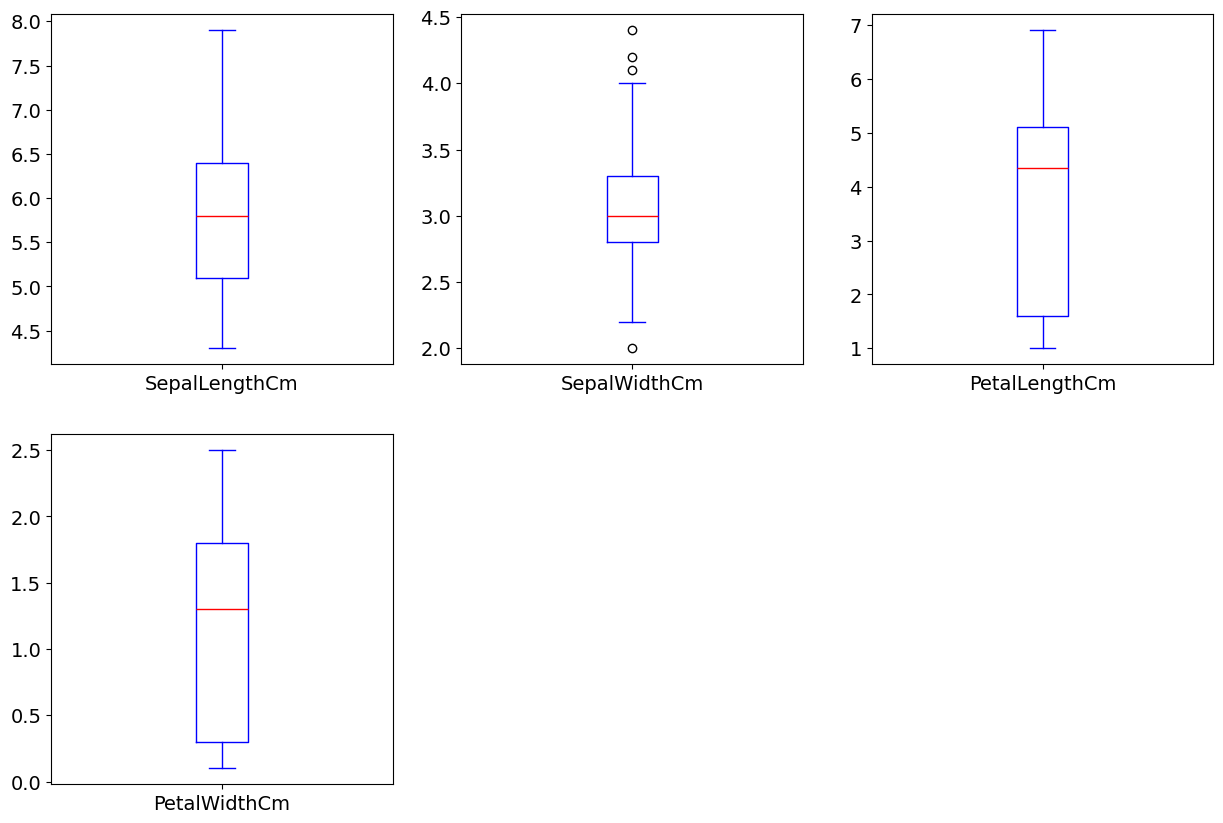

In [14]:
boxplot=iris_data.plot(kind='box', subplots=True, layout=(2,3), sharex=False, sharey=False, colormap='bwr', figsize=(15,10))
print('From the boxplot, it is visible that only sepal width is having the outlier, whereas sepallength, petallength, petalwidth having datapoints within min and maxrange.')
print('It is visible that values in sepallength and sepalwidth are tightly distributed and IQ range is small, whereas in petallength and petalwidth the values are distibuted widely,so IQ range are high.')

In [18]:
iris_data.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.00,-0.11,0.87,0.82
SepalWidthCm,-0.11,1.00,-0.42,-0.36
PetalLengthCm,0.87,-0.42,1.00,0.96
PetalWidthCm,0.82,-0.36,0.96,1.00


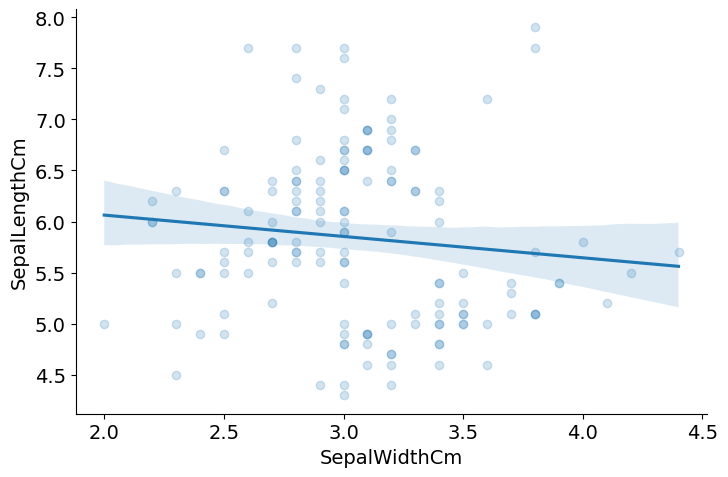

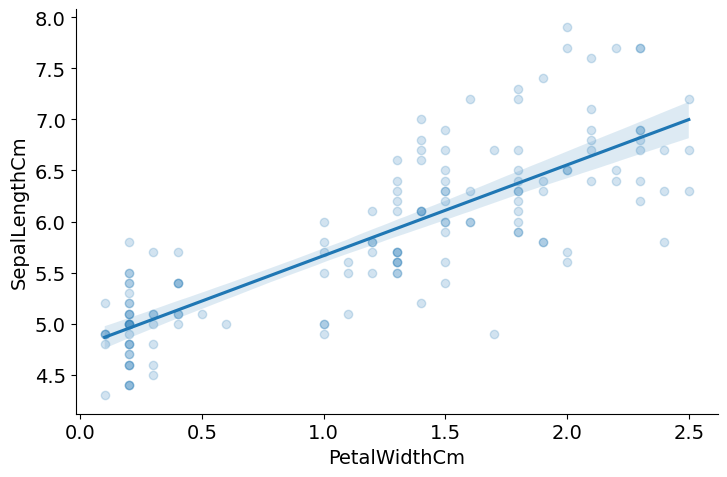

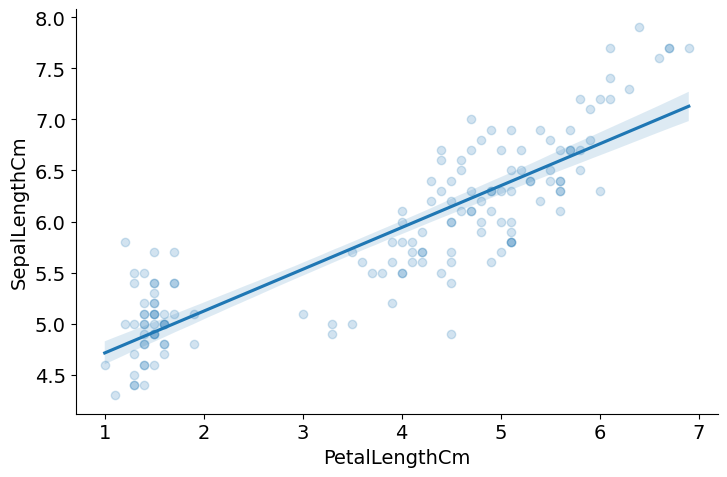

In [19]:
a=sns.lmplot(x='SepalWidthCm', y='SepalLengthCm', data=iris_data, aspect=1.5, scatter_kws={'alpha':0.2})
b=sns.lmplot(x='PetalWidthCm', y='SepalLengthCm', data=iris_data, aspect=1.5, scatter_kws={'alpha':0.2})
c=sns.lmplot(x='PetalLengthCm', y='SepalLengthCm', data=iris_data, aspect=1.5, scatter_kws={'alpha':0.2}) 

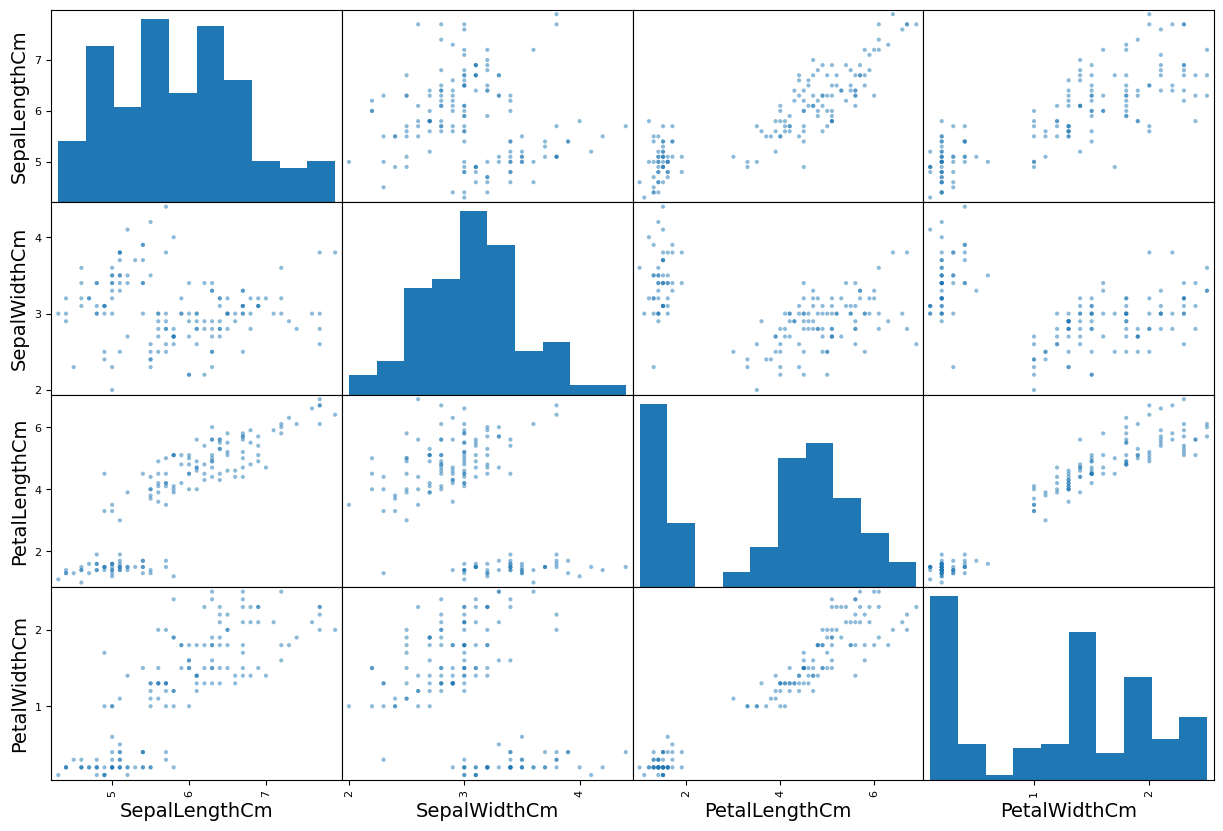

In [20]:
scatter=pd.plotting.scatter_matrix(iris_data,figsize=(15,10))

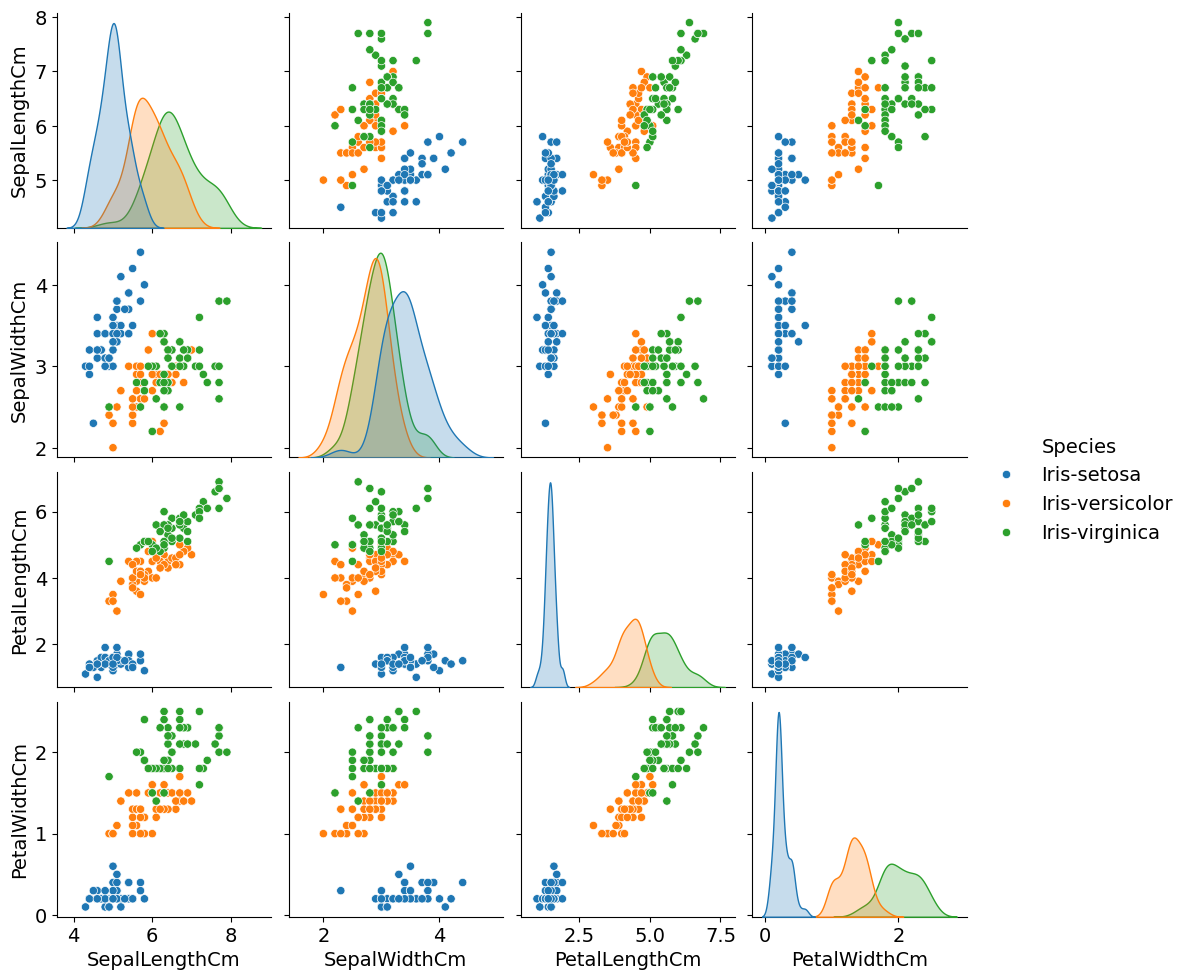

In [21]:
scatterplot=sns.pairplot(iris_data,hue="Species")

In [23]:
input_cols = ['SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = -0.2088*Sepal.Width + 6.481')
print('\n')
print('Holding constant fixed, a 1 centimeter increase in sepalwidth lead to a decrease in Sepalenght by 0.208centimer')


[6.48122321]
[[-0.20887029]]


Sepal.length = -0.2088*Sepal.Width + 6.481


Holding constant fixed, a 1 centimeter increase in sepalwidth lead to a decrease in Sepalenght by 0.208centimer


In [24]:
input_cols = ['PetalLengthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = 0.408*Petal.length + 4.305')
print('\n')
print('Holding constant fixed, a 1 centimeter increase in petallenght lead to a decrease in Sepalenght by 0.409 centimer')


[4.30556546]
[[0.4091259]]


Sepal.length = 0.408*Petal.length + 4.305


Holding constant fixed, a 1 centimeter increase in petallenght lead to a decrease in Sepalenght by 0.409 centimer


In [27]:
input_cols = ['PetalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = 0.408*Petal.width + 4.77')
print('\n')
print('Holding constant fixed, a 1 centimeter increase in petalwidth lead to a increase in Sepalength by 0.887 centimeter')

[4.77949383]
[[0.88751905]]


Sepal.length = 0.408*Petal.width + 4.77


Holding constant fixed, a 1 centimeter increase in petalwidth lead to a increase in Sepalength by 0.887 centimeter


In [31]:
input_cols = ['PetalWidthCm', 'PetalLengthCm', 'SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = -0.56*Petal.Width + 0.71*Petal.Length + 0.65*Sepal.Width + 1.84')
print('\n')
print('Holding all other independent variable fixed, a 1 centimeter decrease in petalwidth lead to a increase in Sepalength by -0.56cm')
print('Holding all other independent variable fixed, a 1 centimeter increase in petallength lead to a increase in Sepalength by 0.71cm')
print('Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.65cm')
print('\n')
print('In given mutivariate model, the petalwidth is showing a negative relation with sepal.length, which proves a level of correlation or dependency between petallength and petalwidth.')
print('This is proved by the correlation matrix as well. Therefore, we have a multicollinearity issue with this model and need to drop one of them.')

[1.8450608]
[[-0.56256786  0.71106291  0.65486424]]


Sepal.length = -0.56*Petal.Width + 0.71*Petal.Length + 0.65*Sepal.Width + 1.84


Holding all other independent variable fixed, a 1 centimeter decrease in petalwidth lead to a increase in Sepalength by -0.56cm
Holding all other independent variable fixed, a 1 centimeter increase in petallength lead to a increase in Sepalength by 0.71cm
Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.65cm


In given mutivariate model, the petalwidth is showing a negative relation with sepal.length, which proves a level of correlation or dependency between petallength and petalwidth.
This is proved by the correlation matrix as well. Therefore, we have a multicollinearity issue with this model and need to drop one of them.


In [32]:
input_cols = ['PetalLengthCm', 'SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]

linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = 0.47*Petal.Length + 0.59*Sepal.Width + 2.25')
print('\n')
print('Holding all other independent variable fixed, a 1 centimeter increase in petallength lead to a increase in Sepalength by 0.47 centimeter')
print('Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.59 centimeter')

[2.2512946]
[[0.47079369 0.59675252]]


Sepal.length = 0.47*Petal.Length + 0.59*Sepal.Width + 2.25


Holding all other independent variable fixed, a 1 centimeter increase in petallength lead to a increase in Sepalength by 0.47 centimeter
Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.59 centimeter


In [33]:
input_cols = ['PetalWidthCm', 'SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]
linreg = LinearRegression()
linreg.fit(X,Y)
print(linreg.intercept_)
print(linreg.coef_)
print('\n')
print('Sepal.length = 0.96*Petal.Width + 0.39*Sepal.Width + 3.46')
print('\n')
print('Holding all other independent variable fixed, a 1 centimeter increase in petalwidth lead to a increase in Sepalength by 0.96 centimeter')
print('Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.39 centimeter')

[3.46477674]
[[0.96830173 0.39878375]]


Sepal.length = 0.96*Petal.Width + 0.39*Sepal.Width + 3.46


Holding all other independent variable fixed, a 1 centimeter increase in petalwidth lead to a increase in Sepalength by 0.96 centimeter
Holding all other independent variable fixed, a 1 centimeter increase in sepalwidth lead to a increase in Sepalength by 0.39 centimeter


In [36]:
import numpy as np
input_cols = ['PetalWidthCm', 'PetalLengthCm', 'SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
Y = iris_data[output_variable]
corr = np.corrcoef(X, rowvar=0)
print(corr) 
print('\n')
print(np.linalg.det(corr))
print('\n')
print('petallength and petalwidth are highly correlated=96% and lead to multicollinearity.')
print('\n')
print('Run the input variable in different combination to find the determinant value.The deteminant of correlation matrix is 0<=D<=1.')
print('D=0, then it indicates exact interdependence of expalanatory variable. D=1, then expalanatory variable independent to each other and have no multicollinearity issue.')
print('\n')
print('1.Determinant value for petalwidth, petallength, sepalwidth =0.057.')
print('2.Determinant value for petallength, sepalwidth =0.816.')
print('3.Determinant value for petalwidth, sepalwidth =0.865.')
print('4.Determinant value for petalwidth, petallength =0.072.')
print('\n')
print('We will avoid the model 1 & 4, as the value of D is close to 0, which indicates the multicollinearity issue. Whereas model 2 & 3 are acceptable, as the value of D is close to 1 and independent variables are not dependent to eachother.')
print('In general, when threshold level is D>0.7, then we can take all the input variables in the model.If D<0.4, then we can say that there is lot of interdependency between variables and we need to drop those variables which are highly correlated and causing multicollinearity.')

[[ 1.          0.9627571  -0.35654409]
 [ 0.9627571   1.         -0.4205161 ]
 [-0.35654409 -0.4205161   1.        ]]


0.05783850919062387


petallength and petalwidth are highly correlated=96% and lead to multicollinearity.


Run the input variable in different combination to find the determinant value.The deteminant of correlation matrix is 0<=D<=1.
D=0, then it indicates exact interdependence of expalanatory variable. D=1, then expalanatory variable independent to each other and have no multicollinearity issue.


1.Determinant value for petalwidth, petallength, sepalwidth =0.057.
2.Determinant value for petallength, sepalwidth =0.816.
3.Determinant value for petalwidth, sepalwidth =0.865.
4.Determinant value for petalwidth, petallength =0.072.


We will avoid the model 1 & 4, as the value of D is close to 0, which indicates the multicollinearity issue. Whereas model 2 & 3 are acceptable, as the value of D is close to 1 and independent variables are not dependent to eachother.
In ge

In [37]:
input_cols = ['PetalLengthCm', 'SepalWidthCm']
output_variable = ['SepalLengthCm']
X = iris_data[input_cols]
y = iris_data[output_variable]
y=iris_data['SepalLengthCm']

In [40]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=12)

In [41]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(105, 2)
(105,)
(45, 2)
(45,)


In [42]:
lin_reg=LinearRegression()
model=lin_reg.fit(X_train,y_train) 

In [43]:
print ('R-Squared for training dataset model:', model.score(X_train,y_train))

print('\n')

print('The high R-Squared value (0.834) from petallength & sepalwidth, implies that petallength & sepalwidth can be relied to explain 83.4% of the variations in sepallength.')

R-Squared for training dataset model: 0.8342913726297885


The high R-Squared value (0.834) from petallength & sepalwidth, implies that petallength & sepalwidth can be relied to explain 83.4% of the variations in sepallength.


In [45]:
print(model.intercept_)
print(model.coef_)

2.208866408414514
[0.47403504 0.60231447]


In [46]:
predicted=model.predict(X_test)

In [47]:
print ('MAE:', metrics.mean_absolute_error(y_test, predicted))
print ('MSE:', metrics.mean_squared_error(y_test, predicted))
print ('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predicted)))

MAE: 0.24397281467906037
MSE: 0.09431993312135639
RMSE: 0.30711550452778574


In [48]:
print(metrics.r2_score(y_test, predicted))

0.8447727117366579


In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
y_null = np.zeros_like(y_test, dtype=float)
y_null.fill(y_test.mean())
y_null

array([5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556,
       5.67555556, 5.67555556, 5.67555556, 5.67555556, 5.67555556])

In [50]:
print(y_test.shape)
print(y_null.shape)

(45,)
(45,)


In [51]:
np.sqrt(metrics.mean_squared_error(y_test, y_null))

np.float64(0.7795028488453551)

In [52]:
feature_cols=['PetalWidthCm','PetalLengthCm', 'SepalWidthCm']

In [53]:
def train_test_rmse(feature_cols):
    X = iris_data[feature_cols]
    y=iris_data['SepalLengthCm']
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    return np.sqrt(metrics.mean_squared_error(y_test, y_pred))

In [54]:
print (train_test_rmse(['PetalWidthCm','PetalLengthCm', 'SepalWidthCm']))
print (train_test_rmse(['PetalWidthCm', 'SepalWidthCm']))
print (train_test_rmse(['PetalLengthCm', 'SepalWidthCm']))

0.3235340202101116
0.3743279644056068
0.30711550452778574


In [55]:
def train_test_mse(feature_cols):
    X = iris_data[feature_cols]
    y=iris_data['SepalLengthCm']
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3,random_state=12)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    return metrics.mean_squared_error(y_test, y_pred)

In [56]:
print (train_test_mse(['PetalWidthCm','PetalLengthCm', 'SepalWidthCm']))
print (train_test_mse(['PetalWidthCm', 'SepalWidthCm']))
print (train_test_mse(['PetalLengthCm', 'SepalWidthCm']))

0.1046742622333169
0.1401214249360452
0.09431993312135639


In [57]:
def train_test_mae(feature_cols):
    X = iris_data[feature_cols]
    y=iris_data['SepalLengthCm']
    X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)
    y_pred = linreg.predict(X_test)
    return metrics.mean_absolute_error(y_test, y_pred)

In [58]:
print (train_test_mae(['PetalWidthCm','PetalLengthCm', 'SepalWidthCm']))
print (train_test_mae(['PetalWidthCm', 'SepalWidthCm']))
print (train_test_mae(['PetalLengthCm', 'SepalWidthCm']))

0.25617240197816193
0.28745969086322243
0.24397281467906037


In [59]:
iris_data.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.10,3.50,1.40,0.20,Iris-setosa
1,4.90,3.00,1.40,0.20,Iris-setosa
2,4.70,3.20,1.30,0.20,Iris-setosa
3,4.60,3.10,1.50,0.20,Iris-setosa
4,5.00,3.60,1.40,0.20,Iris-setosa


In [60]:
Species_dummies = pd.get_dummies(iris_data.Species, prefix='Species')
Species_dummies.sample(n=5, random_state=12)

,Species_Iris-setosa,Species_Iris-versicolor,Species_Iris-virginica
40,True,False,False
146,False,False,True
38,True,False,False
99,False,True,False
143,False,False,True


In [61]:
Species_dummies.drop(Species_dummies .columns[0], axis=1, inplace=True)
iris_data = pd.concat([iris_data, Species_dummies], axis=1)
iris_data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Species_Iris-versicolor,Species_Iris-virginica
0,5.10,3.50,1.40,0.20,Iris-setosa,False,False
1,4.90,3.00,1.40,0.20,Iris-setosa,False,False
2,4.70,3.20,1.30,0.20,Iris-setosa,False,False
3,4.60,3.10,1.50,0.20,Iris-setosa,False,False
4,5.00,3.60,1.40,0.20,Iris-setosa,False,False


In [63]:
iris_data.corr(numeric_only=True)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species_Iris-versicolor,Species_Iris-virginica
SepalLengthCm,1.00,-0.11,0.87,0.82,0.08,0.64
SepalWidthCm,-0.11,1.00,-0.42,-0.36,-0.46,-0.13
PetalLengthCm,0.87,-0.42,1.00,0.96,0.20,0.72
PetalWidthCm,0.82,-0.36,0.96,1.00,0.12,0.77
Species_Iris-versicolor,0.08,-0.46,0.20,0.12,1.00,-0.50
Species_Iris-virginica,0.64,-0.13,0.72,0.77,-0.50,1.00


In [64]:
feature_dummies1 =['PetalLengthCm', 'SepalWidthCm', 'Species_Iris-versicolor','Species_Iris-virginica']
X = iris_data[feature_dummies1]
y = iris_data['SepalLengthCm']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print(linreg.intercept_)
print(list(zip(feature_dummies1, linreg.coef_)))
print('\n')
print('Predicted value of Sepal length:', y_pred)

2.578853106278608
[('PetalLengthCm', np.float64(0.8587698166003921)), ('SepalWidthCm', np.float64(0.3388495872506321)), ('Species_Iris-versicolor', np.float64(-1.258087196491359)), ('Species_Iris-virginica', np.float64(-1.78400133910691))]


Predicted value of Sepal length: [4.88122742 5.93582482 4.71180263 5.790501   6.94591236 6.53463452
 6.58429737 5.01909643 7.04989641 5.15696543 6.20177885 5.01676726
 5.01909643 5.1207513  6.44130273 7.03178935 6.62284067 5.9441479
 4.93321945 6.37586198 4.79767961 5.70462402 5.86572573 6.16789389
 5.36260435 6.27700358 6.63116375 5.98036203 5.10497341 4.47460792
 4.9671044  5.31145324 6.58662654 5.20429912 6.08947172 5.35794602
 5.39500105 5.39733022 4.96477524 5.50131427 4.74419933 5.10497341
 4.76379465 5.15463626 4.79767961]


In [65]:
feature_dummies2 =['PetalWidthCm','SepalWidthCm', 'Species_Iris-versicolor','Species_Iris-virginica']
X = iris_data[feature_dummies2]
y = iris_data['SepalLengthCm']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print (linreg.intercept_)
print (list(zip(feature_dummies2, linreg.coef_)))
print('\n')
print('Predicted value:', y_pred)

2.298453006161822
[('PetalWidthCm', np.float64(0.27616592539757395)), ('SepalWidthCm', np.float64(0.7750130519613835)), ('Species_Iris-versicolor', np.float64(1.1275981899973289)), ('Species_Iris-virginica', np.float64(1.4146501108246183))]


Predicted value: [5.09384847 6.17535101 4.67872535 5.95510344 6.82832651 6.53524094
 6.98332912 4.98873057 6.6733239  4.99407904 6.16533924 5.43147028
 5.04396375 5.27646767 6.29272526 6.69024355 6.14773441 6.16533924
 5.01634716 5.77783271 4.67872535 5.95510344 6.38023833 6.08783793
 4.98873057 6.6733239  6.22057243 5.77248424 4.98873057 4.1638328
 5.09384847 5.56224845 6.45773963 5.60874101 6.33035362 5.8189768
 6.03260475 5.58986504 5.4537384  5.40724584 5.66736634 5.04396375
 4.60122404 5.32635238 4.65110875]


In [66]:
feature_dummies3 =['PetalLengthCm', 'PetalWidthCm','SepalWidthCm', 'Species_Iris-versicolor','Species_Iris-virginica']
X = iris_data[feature_dummies3]
y = iris_data['SepalLengthCm']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=12)
linreg = LinearRegression()
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
print (linreg.intercept_)
print (list(zip(feature_dummies3, linreg.coef_)))
print('\n')
print('Predicted value:', y_pred)

print('\n')

print('This model is not effective due to multicollinearity b/w the independent variables, petal length and width.')

2.244426174761839
[('PetalLengthCm', np.float64(0.9195490933159172)), ('PetalWidthCm', np.float64(-0.3967907836074813)), ('SepalWidthCm', np.float64(0.43621803760158334)), ('Species_Iris-versicolor', np.float64(-0.9280006320752068)), ('Species_Iris-virginica', np.float64(-1.272117336524105))]


Predicted value: [4.84756589 5.90669691 4.66913595 5.79215931 6.88092741 6.62425955
 6.50839647 5.02753299 6.97759362 5.04878377 6.1678644  4.98237403
 4.94817483 5.07904024 6.4786969  7.17127771 6.68201526 5.89199967
 4.895899   6.31757502 4.76109086 5.7002044  5.89333158 6.1242426
 5.39535262 6.14999943 6.54828079 6.02045951 5.1194879  4.32410425
 4.9395208  5.36888969 6.67259266 5.28455251 6.08589543 5.38439287
 5.37600657 5.42116553 5.01339908 5.55751082 4.72914805 5.04012974
 4.71746906 5.16234112 4.80076994]


This model is not effective due to multicollinearity b/w the independent variables, petal length and width.


In [67]:
print (train_test_rmse(['PetalLengthCm', 'Species_Iris-versicolor','Species_Iris-virginica','SepalWidthCm']))
print (train_test_rmse(iris_data.columns[iris_data.columns.str.startswith('Species_')]))
print (train_test_rmse(['PetalWidthCm', 'Species_Iris-versicolor','Species_Iris-virginica','SepalWidthCm']))

print('\n')

print('We can see among the calculated rmse value, the least rmse value is for the petal length, species_ and it is better than other rmse value. So, model#1 it is a best model to consider.')

0.32663630147017003
0.4534843521508058
0.36392596215820044


We can see among the calculated rmse value, the least rmse value is for the petal length, species_ and it is better than other rmse value. So, model#1 it is a best model to consider.
